# Material Classification from Multipath Profiles -- Random Forest Feature Importance

This notebook is a companion to `material_classifier_4.ipynb`. It re-uses the exact same file loading, MATLAB parsing, and feature-extraction pipeline, but swaps the PyTorch MLP for a `RandomForestClassifier` so we can inspect **feature importance** and better understand which measurements actually drive the material prediction.

**What's different from the MLP notebook:**
- No PyTorch, `Dataset`/`DataLoader`, or GPU device -- Random Forests just need a 2D NumPy feature matrix `(n_examples, n_features)` and a label vector.
- `aux` and `peak_struct` are **concatenated into a single feature matrix** instead of being kept as two separate model inputs, since a Random Forest takes one flat input.
- Features are **not z-scored**. Random Forests split on raw thresholds and are scale-invariant, so normalizing would only make the feature-importance plots and split thresholds harder to read in physical units (degrees, dB, meters, etc.) for no modeling benefit. We still impute missing values with the column mean, same as before.
- The file-level train/val/test split, and the grouped K-fold robustness check, are both reused unchanged -- they don't depend on the model type.

## Package Requirements

In [39]:
# Uncomment only if you are missing packages.
#
#%pip install numpy scipy matplotlib scikit-learn

# 1. Imports and Configuration

In [40]:
from pathlib import Path
from typing import Any, Dict, List, Tuple
import random
import re

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance

import sklearn

In [41]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

# 2. Locate the MATLAB Data

In [42]:
DATA_DIR = Path("Processed_Data_Points (missing rows)/combined with all rows/")

mat_files = sorted(DATA_DIR.glob("*.mat"))

print("Data directory:", DATA_DIR.resolve())
print("Number of .mat files found:", len(mat_files))

if len(mat_files) == 0:
    print("\nNo .mat files were found. Make sure your files are in projects/p3/data/*.mat")

Data directory: C:\Users\WINGS\Documents\Ashley\WINGS-2026\Processed_Data_Points (missing rows)\combined with all rows
Number of .mat files found: 54


# 3. Helper Functions for MATLAB Arrays

Identical to the MLP notebook. Converts a MATLAB variable into a clean 2D NumPy array with shape `(examples, samples)`.

In [43]:
def numeric_2d(value: Any) -> np.ndarray:
    """
    Convert a MATLAB numeric profile-like variable to a 2D NumPy array.

    Output shape:
        (number_of_examples, number_of_samples)
    """
    arr = np.asarray(value)

    if arr.dtype == object:
        rows = []
        for item in arr.ravel():
            item_arr = np.asarray(item).squeeze().ravel()
            if item_arr.size > 0:
                rows.append(item_arr)

        if len(rows) == 0:
            return np.empty((0, 0), dtype=np.float32)

        max_len = max(len(row) for row in rows)
        out = np.full((len(rows), max_len), np.nan, dtype=np.float32)

        for i, row in enumerate(rows):
            out[i, : len(row)] = np.asarray(row, dtype=np.float32)

        return out

    arr = np.squeeze(arr)

    if arr.ndim == 0:
        return arr.reshape(1, 1).astype(np.float32)

    if arr.ndim == 1:
        return arr.reshape(1, -1).astype(np.float32)

    if arr.ndim == 2:
        if arr.shape[0] > 1000 and arr.shape[1] < 1000:
            arr = arr.T
        return arr.astype(np.float32)

    return arr.reshape(arr.shape[0], -1).astype(np.float32)

# 4. Parse Material Labels from Filenames

In [44]:
MATERIALS = ["wood", "drywall", "glass", "metal"]

FILENAME_RE = re.compile(
    r"""
    ^data
    _BW_(?P<bw>\d+(?:\.\d+)?)GHz
    _RF_(?P<rf>\d+(?:\.\d+)?)GHz
    (?P<material>[A-Za-z0-9]+)
    _Angle(?P<angle>\d+(?:\.\d+)?)
    _Power_(?P<power>-?\d+(?:\.\d+)?)
    \.mat$
    """,
    re.VERBOSE,
)

def parse_filename(path: Path) -> Dict[str, Any]:
    """Parse useful metadata from a MATLAB filename."""
    match = FILENAME_RE.match(path.name)

    if match is not None:
        return {
            "filename": path.name,
            "material": match.group("material").lower(),
            "angle_deg": float(match.group("angle")),
            "power": float(match.group("power")),
            "bandwidth_ghz": float(match.group("bw")),
            "rf_ghz": float(match.group("rf")),
        }

    lower_name = path.name.lower()
    material = "unknown"
    for candidate in MATERIALS:
        if candidate in lower_name:
            material = candidate
            break

    return {
        "filename": path.name,
        "material": material,
        "angle_deg": np.nan,
        "power": np.nan,
        "bandwidth_ghz": np.nan,
        "rf_ghz": np.nan,
    }

for path in mat_files[:5]:
    print(parse_filename(path))

{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_125.mat', 'material': 'drywall', 'angle_deg': 45.0, 'power': 125.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_176.mat', 'material': 'drywall', 'angle_deg': 45.0, 'power': 176.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_250.mat', 'material': 'drywall', 'angle_deg': 45.0, 'power': 250.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_354.mat', 'material': 'drywall', 'angle_deg': 45.0, 'power': 354.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_500.mat', 'material': 'drywall', 'angle_deg': 45.0, 'power': 500.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}


# 5. Feature Extraction Helpers

Same field-level extraction logic as the MLP notebook -- per-file scalars, per-row values, per-row array summary stats, and paired top-K peak (value, location) extraction. Kept unchanged so the two notebooks are directly comparable feature-for-feature.

In [45]:
AUX_FEATURE_NAMES = [
    "v_angle",
    "v_Power_Tx",
    "K_dB",
    "PDP_RMS",
    "distance_Rx",
    "distance_Tx",
    "P_sig_dBm_mean",
    "P_sig_dBm_range",
]

N_TOP_PEAKS = 8  # TODO: try 3-8. Limited by how many peaks the detector typically resolves.

PEAK_STRUCT_FEATURE_NAMES = (
    ["peak_val_IF_count"]
    + [f"peak_val_top{i + 1}" for i in range(N_TOP_PEAKS)]
    + [f"peak_loc_top{i + 1}" for i in range(N_TOP_PEAKS)]
)

# The single feature matrix the Random Forest will actually see: aux + peak-structured,
# concatenated in a fixed order so feature_importances_[i] always lines up with
# FEATURE_NAMES[i].
FEATURE_NAMES = AUX_FEATURE_NAMES + PEAK_STRUCT_FEATURE_NAMES

EXPECTED_PROFILE_ROWS = 48

def scalar_from_mat(mat: Dict[str, Any], key: str) -> float:
    """Pull a single per-file scalar out of a loaded .mat dict."""
    if key not in mat:
        return float("nan")
    try:
        value = float(np.asarray(mat[key]).squeeze())
    except Exception:
        return float("nan")
    return value if np.isfinite(value) else float("nan")


def row_value_from_mat(mat: Dict[str, Any], key: str, row_idx: int) -> float:
    """Pull a per-row value for a given profile row."""
    if key not in mat:
        return float("nan")
    arr = np.asarray(mat[key]).squeeze().ravel()
    if row_idx < arr.size:
        try:
            value = float(arr[row_idx])
        except Exception:
            return float("nan")
        return value if np.isfinite(value) else float("nan")
    return float("nan")


def row_array_stats_from_mat(mat: Dict[str, Any], key: str, row_idx: int) -> Dict[str, float]:
    """Pull a per-row array and reduce it to scalar summary statistics for one row."""
    nan_stats = {
        "count": float("nan"), "mean": float("nan"), "max": float("nan"),
        "min": float("nan"), "range": float("nan"),
    }

    if key not in mat:
        return dict(nan_stats)

    arr = numeric_2d(mat[key])

    if arr.size == 0 or row_idx >= arr.shape[0]:
        return dict(nan_stats)

    row = np.asarray(arr[row_idx], dtype=np.float64).ravel()
    row = row[np.isfinite(row)]

    if row.size == 0:
        return dict(nan_stats)

    row_max = float(np.max(row))
    row_min = float(np.min(row))

    return {
        "count": float(row.size), "mean": float(np.mean(row)),
        "max": row_max, "min": row_min, "range": row_max - row_min,
    }


def top_k_peaks_from_mat(
    mat: Dict[str, Any], val_key: str, loc_key: str, row_idx: int, k: int = N_TOP_PEAKS,
) -> Tuple[np.ndarray, np.ndarray]:
    """Extract up to k strongest detected multipath peaks for one row, value paired with location."""
    nan_out = np.full(k, np.nan, dtype=np.float64)

    if val_key not in mat or loc_key not in mat:
        return nan_out.copy(), nan_out.copy()

    val_arr = numeric_2d(mat[val_key])
    loc_arr = numeric_2d(mat[loc_key])

    if row_idx >= val_arr.shape[0] or row_idx >= loc_arr.shape[0]:
        return nan_out.copy(), nan_out.copy()

    vals_row = np.asarray(val_arr[row_idx], dtype=np.float64)
    locs_row = np.asarray(loc_arr[row_idx], dtype=np.float64)

    n = min(vals_row.size, locs_row.size)
    vals_row = vals_row[:n]
    locs_row = locs_row[:n]
    finite_mask = np.isfinite(vals_row) & np.isfinite(locs_row)
    vals_row = vals_row[finite_mask]
    locs_row = locs_row[finite_mask]

    if vals_row.size == 0:
        return nan_out.copy(), nan_out.copy()

    order = np.argsort(vals_row)[::-1]
    vals_sorted = vals_row[order]
    locs_sorted = locs_row[order]

    out_vals = nan_out.copy()
    out_locs = nan_out.copy()
    take = min(k, vals_sorted.size)
    out_vals[:take] = vals_sorted[:take]
    out_locs[:take] = locs_sorted[:take]

    return out_vals, out_locs

# 6. Build the Feature Matrix

`MultipathMaterialFeatures` plays the same role as `MultipathMaterialDataset` in the MLP notebook, but instead of a PyTorch `Dataset` it's a plain object holding NumPy arrays:

- `X`: shape `(n_rows, n_aux_features + n_peak_struct_features)` -- the single flat feature matrix a Random Forest expects, in raw (unscaled) units, NaNs imputed with the column mean.
- `y`: integer labels (0=wood, 1=drywall, 2=glass, 3=metal).
- `meta`: per-row metadata (filename, angle, power, row index) -- needed for the file-level train/test split below.
- `feature_names`: column names for `X`, in the same order, so importances line up.

In [46]:
class MultipathMaterialFeatures:
    """Flat feature-matrix builder for material classification (Random Forest friendly)."""

    def __init__(
        self,
        root: Path,
        mp_key: str = "Multipath_Profile_X_corr_IF",
        materials: List[str] = None,
        aux_feature_names: List[str] = None,
        expected_profile_rows: int = EXPECTED_PROFILE_ROWS,
        verbose: bool = True,
    ):
        self.root = Path(root)
        self.mp_key = mp_key
        self.materials = materials if materials is not None else ["wood", "drywall", "glass", "metal"]
        self.material_to_label = {name: i for i, name in enumerate(self.materials)}
        self.label_to_material = {i: name for name, i in self.material_to_label.items()}
        self.aux_feature_names = aux_feature_names if aux_feature_names is not None else list(AUX_FEATURE_NAMES)
        self.peak_struct_feature_names = list(PEAK_STRUCT_FEATURE_NAMES)
        self.feature_names = self.aux_feature_names + self.peak_struct_feature_names
        self.expected_profile_rows = expected_profile_rows

        self.labels: List[int] = []
        self.meta: List[Dict[str, Any]] = []
        self.raw_rows: List[List[float]] = []
        self.skipped_row_mismatch: List[str] = []

        files = sorted(self.root.glob("*.mat"))

        if len(files) == 0:
            raise RuntimeError(f"No .mat files found in {self.root}")

        for path in files:
            info = parse_filename(path)
            material = info["material"]

            if material not in self.material_to_label:
                if verbose:
                    print(f"[skip] {path.name}: unknown material {material!r}")
                continue

            try:
                mat = loadmat(path, squeeze_me=False, struct_as_record=False)
            except Exception as exc:
                if verbose:
                    print(f"[skip] {path.name}: could not load file: {exc}")
                continue

            if self.mp_key not in mat:
                if verbose:
                    print(f"[skip] {path.name}: missing variable {self.mp_key}")
                continue

            profiles_2d = numeric_2d(mat[self.mp_key])

            if profiles_2d.size == 0:
                if verbose:
                    print(f"[skip] {path.name}: empty multipath variable")
                continue

            if profiles_2d.shape[0] != self.expected_profile_rows:
                if verbose:
                    print(
                        f"[skip] {path.name}: expected {self.expected_profile_rows} profile rows, "
                        f"found {profiles_2d.shape[0]} (row-level features would not line up safely)"
                    )
                self.skipped_row_mismatch.append(path.name)
                continue

            v_angle = scalar_from_mat(mat, "v_angle")
            v_power_tx = scalar_from_mat(mat, "v_Power_Tx")

            peak_val_arr = np.asarray(mat["peak_val_IF"]) if "peak_val_IF" in mat else None
            peak_loc_arr = np.asarray(mat["peak_loc_IF"]) if "peak_loc_IF" in mat else None

            peak_rows_aligned = True
            for arr, arr_name in [(peak_val_arr, "peak_val_IF"), (peak_loc_arr, "peak_loc_IF")]:
                if arr is not None and arr.shape[0] != profiles_2d.shape[0]:
                    peak_rows_aligned = False
                    if verbose:
                        print(
                            f"[warn] {path.name}: {arr_name} has {arr.shape[0]} rows but the "
                            f"profile has {profiles_2d.shape[0]} rows; peak-derived features "
                            "for this file will be treated as missing rather than risk misalignment."
                        )

            for row_idx in range(profiles_2d.shape[0]):
                self.labels.append(self.material_to_label[material])

                k_db = row_value_from_mat(mat, "K_dB", row_idx)
                pdp_rms = row_value_from_mat(mat, "PDP_RMS", row_idx)
                distance_rx = row_value_from_mat(mat, "distance_Rx", row_idx)
                distance_tx = row_value_from_mat(mat, "distance_Tx", row_idx)

                p_sig_stats = row_array_stats_from_mat(mat, "P_sig_dBm", row_idx)

                if peak_rows_aligned:
                    peak_val_stats = row_array_stats_from_mat(mat, "peak_val_IF", row_idx)
                else:
                    peak_val_stats = {"count": float("nan")}

                aux_lookup = {
                    "v_angle": v_angle,
                    "v_Power_Tx": v_power_tx,
                    "K_dB": k_db,
                    "PDP_RMS": pdp_rms,
                    "distance_Rx": distance_rx,
                    "distance_Tx": distance_tx,
                    "P_sig_dBm_mean": p_sig_stats["mean"],
                    "P_sig_dBm_range": p_sig_stats["range"],
                }

                if peak_rows_aligned:
                    peak_vals_topk, peak_locs_topk = top_k_peaks_from_mat(
                        mat, "peak_val_IF", "peak_loc_IF", row_idx, k=N_TOP_PEAKS
                    )
                else:
                    peak_vals_topk = np.full(N_TOP_PEAKS, np.nan)
                    peak_locs_topk = np.full(N_TOP_PEAKS, np.nan)

                peak_struct_lookup = {"peak_val_IF_count": peak_val_stats["count"]}
                for i in range(N_TOP_PEAKS):
                    peak_struct_lookup[f"peak_val_top{i + 1}"] = peak_vals_topk[i]
                    peak_struct_lookup[f"peak_loc_top{i + 1}"] = peak_locs_topk[i]

                row_lookup = {**aux_lookup, **peak_struct_lookup}
                self.raw_rows.append([row_lookup[name] for name in self.feature_names])

                row_meta = dict(info)
                row_meta["row"] = row_idx
                self.meta.append(row_meta)

        if len(self.labels) == 0:
            raise RuntimeError("No valid multipath profiles were loaded.")

        self.y = np.asarray(self.labels, dtype=np.int64)

        raw_X = np.asarray(self.raw_rows, dtype=np.float64)
        nonfinite_counts = np.isnan(raw_X).sum(axis=0)

        col_means = np.nanmean(raw_X, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_mask = np.isnan(raw_X)
        for col in range(raw_X.shape[1]):
            raw_X[nan_mask[:, col], col] = col_means[col]

        self.X = raw_X.astype(np.float32)

        if verbose:
            print(f"Loaded {len(self)} examples from {len(files)} .mat files")
            print(f"Skipped {len(self.skipped_row_mismatch)} files due to row-count mismatch")
            if self.skipped_row_mismatch:
                print("  e.g.:", self.skipped_row_mismatch[:10])
            print("Feature matrix shape:", self.X.shape)
            print(
                "Non-finite values replaced with column mean (per feature):",
                dict(zip(self.feature_names, nonfinite_counts.tolist())),
            )
            print("Materials:", self.material_to_label)

    def __len__(self):
        return len(self.y)

## Create the Feature Matrix

Same important settings as the MLP notebook:
- `mp_key`: MATLAB variable name for the multipath profile (used to validate row counts)
- `expected_profile_rows`: files with a different row count are skipped

In [47]:
MP_KEY = "Multipath_Profile_X_corr_IF"  # update only if your MATLAB variable has a different name.

features = MultipathMaterialFeatures(
    root=DATA_DIR,
    mp_key=MP_KEY,
    verbose=True,
)

print("X shape:", features.X.shape)
print("First row:", features.X[0])
print("First label:", features.y[0], "->", features.label_to_material[int(features.y[0])])

Loaded 2592 examples from 54 .mat files
Skipped 0 files due to row-count mismatch
Feature matrix shape: (2592, 25)
Non-finite values replaced with column mean (per feature): {'v_angle': 0, 'v_Power_Tx': 0, 'K_dB': 105, 'PDP_RMS': 0, 'distance_Rx': 0, 'distance_Tx': 0, 'P_sig_dBm_mean': 0, 'P_sig_dBm_range': 0, 'peak_val_IF_count': 29, 'peak_val_top1': 29, 'peak_val_top2': 57, 'peak_val_top3': 124, 'peak_val_top4': 303, 'peak_val_top5': 459, 'peak_val_top6': 625, 'peak_val_top7': 743, 'peak_val_top8': 862, 'peak_loc_top1': 29, 'peak_loc_top2': 57, 'peak_loc_top3': 124, 'peak_loc_top4': 303, 'peak_loc_top5': 459, 'peak_loc_top6': 625, 'peak_loc_top7': 743, 'peak_loc_top8': 862}
Materials: {'wood': 0, 'drywall': 1, 'glass': 2, 'metal': 3}
X shape: (2592, 25)
First row: [ 4.5000000e+01  1.2500000e+02  3.1693769e+01  2.2243575e-10
  1.0000000e+00  1.0000000e+00 -3.5473763e+01  6.5448761e-01
  7.0000000e+00 -3.3557404e+01 -6.0024467e+01 -6.1822121e+01
 -7.0141983e+01 -7.3496719e+01 -7.463582

# 7. Train / Validation / Test Split

Unchanged from the MLP notebook, and for the same reason: **we split by *file*, not by row.** Each `.mat` file contributes ~44-48 rows from the *same* physical measurement, so splitting at the row level would leak file-specific quirks between train and test. Files are assigned to train/val/test first (stratified by material), and every row from a file follows its file's split.

In [48]:
def stratified_split_files(
    meta: List[Dict[str, Any]],
    labels: np.ndarray,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = 42,
) -> Tuple[List[int], List[int], List[int]]:
    """Create train/validation/test indices, splitting whole *files* at a time."""
    rng = random.Random(seed)
    labels = np.asarray(labels)

    file_to_label: Dict[str, int] = {}
    file_to_row_indices: Dict[str, List[int]] = {}

    for idx, row_meta in enumerate(meta):
        fname = row_meta["filename"]
        file_to_label.setdefault(fname, int(labels[idx]))
        file_to_row_indices.setdefault(fname, []).append(idx)

    files_by_label: Dict[int, List[str]] = {}
    for fname, label in file_to_label.items():
        files_by_label.setdefault(label, []).append(fname)

    train_files: List[str] = []
    val_files: List[str] = []
    test_files: List[str] = []

    for label, files in files_by_label.items():
        files = list(files)
        rng.shuffle(files)

        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_files.extend(files[:n_train])
        val_files.extend(files[n_train:n_train + n_val])
        test_files.extend(files[n_train + n_val:])

    def files_to_indices(file_list: List[str]) -> List[int]:
        indices: List[int] = []
        for fname in file_list:
            indices.extend(file_to_row_indices[fname])
        return indices

    train_indices = files_to_indices(train_files)
    val_indices = files_to_indices(val_files)
    test_indices = files_to_indices(test_files)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    print(f"Files -> train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    return train_indices, val_indices, test_indices

train_idx, val_idx, test_idx = stratified_split_files(features.meta, features.y, seed=SEED)

X_train, y_train = features.X[train_idx], features.y[train_idx]
X_val, y_val = features.X[val_idx], features.y[val_idx]
X_test, y_test = features.X[test_idx], features.y[test_idx]

print("Train examples:", len(X_train))
print("Validation examples:", len(X_val))
print("Test examples:", len(X_test))

Files -> train: 36, val: 7, test: 11
Train examples: 1728
Validation examples: 336
Test examples: 528


# 8. Train the Random Forest

A few design choices worth calling out:

- **`class_weight="balanced"`**: if the materials aren't perfectly balanced in file count, this reweights classes inversely to their frequency so the forest doesn't just learn to favor the majority material.
- **`n_estimators=300`**: enough trees for importance/permutation estimates to be stable run-to-run; increase if you see importances shifting noticeably between reruns with different seeds.
- **`max_depth`, `min_samples_leaf`**: left fairly permissive to start, then tuned against the validation set below -- with correlated features (e.g. the 8 peak values are all somewhat redundant with each other) deep, unconstrained trees can overfit to file-specific noise.
- We use the **validation set** to pick `max_depth`, the same role it played for early-stopping intuition in the MLP notebook, then report final numbers on the held-out **test set**.

In [49]:
param_grid = [
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_leaf": 3},
    {"max_depth": 10, "min_samples_leaf": 1},
    {"max_depth": 10, "min_samples_leaf": 3},
    {"max_depth": 5, "min_samples_leaf": 3},
]

best_val_acc = -1.0
best_params = None

for params in param_grid:
    candidate = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        **params,
    )
    candidate.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, candidate.predict(X_val))
    print(f"{params} -> val accuracy: {100 * val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

print("\nBest params:", best_params, f"(val accuracy {100 * best_val_acc:.2f}%)")

{'max_depth': None, 'min_samples_leaf': 1} -> val accuracy: 49.40%
{'max_depth': None, 'min_samples_leaf': 3} -> val accuracy: 47.32%
{'max_depth': 10, 'min_samples_leaf': 1} -> val accuracy: 50.30%
{'max_depth': 10, 'min_samples_leaf': 3} -> val accuracy: 49.70%
{'max_depth': 5, 'min_samples_leaf': 3} -> val accuracy: 50.30%

Best params: {'max_depth': 10, 'min_samples_leaf': 1} (val accuracy 50.30%)


In [50]:
# Refit on train + val with the chosen hyperparameters, holding test out completely,
# then evaluate once on test.
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    **best_params,
)
model.fit(X_trainval, y_trainval)

train_acc = accuracy_score(y_trainval, model.predict(X_trainval))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Train+val accuracy: {100 * train_acc:.2f}%")
print(f"Test accuracy:      {100 * test_acc:.2f}%")

Train+val accuracy: 97.43%
Test accuracy:      33.33%


# 9. Test Set Report and Confusion Matrix

              precision    recall  f1-score   support

        wood       0.67      0.82      0.74       144
     drywall       0.27      0.20      0.23       144
       glass       0.25      0.19      0.22       144
       metal       0.01      0.01      0.01        96

    accuracy                           0.33       528
   macro avg       0.30      0.31      0.30       528
weighted avg       0.33      0.33      0.32       528



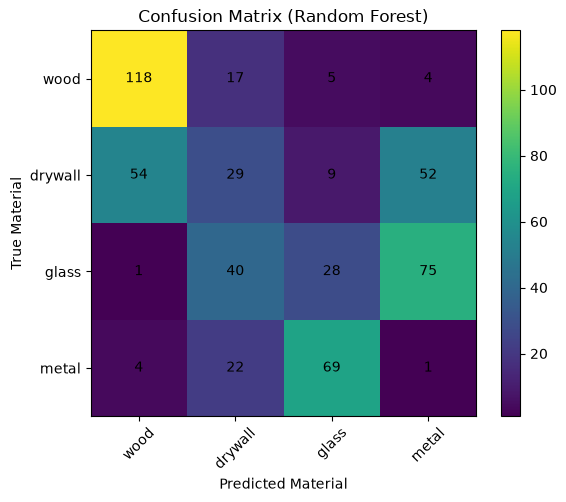

In [51]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=features.materials))

def make_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[int(true_label), int(pred_label)] += 1
    return cm

NUM_CLASSES = len(features.materials)
cm = make_confusion_matrix(y_test, y_pred, num_classes=NUM_CLASSES)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted Material")
plt.ylabel("True Material")
plt.xticks(range(NUM_CLASSES), features.materials, rotation=45)
plt.yticks(range(NUM_CLASSES), features.materials)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# 10. Feature Importance

Two complementary views, since they can disagree and each has known failure modes:

- **Impurity-based importance** (`model.feature_importances_`): fast, built into the forest, but biased toward high-cardinality / continuous features and can over-credit a feature just because it was available for more splits -- and it's measured on training data, so it can reflect overfitting.
- **Permutation importance** (`sklearn.inspection.permutation_importance`): measures how much test accuracy drops when a feature's values are shuffled, so it's measured out-of-sample and isn't biased by feature cardinality. This is generally the more trustworthy of the two, especially with our peak-value/location features which are highly correlated with each other (shuffling one correlated feature barely hurts, since the forest can lean on its neighbors -- worth keeping in mind when interpreting low scores for individual peak features).

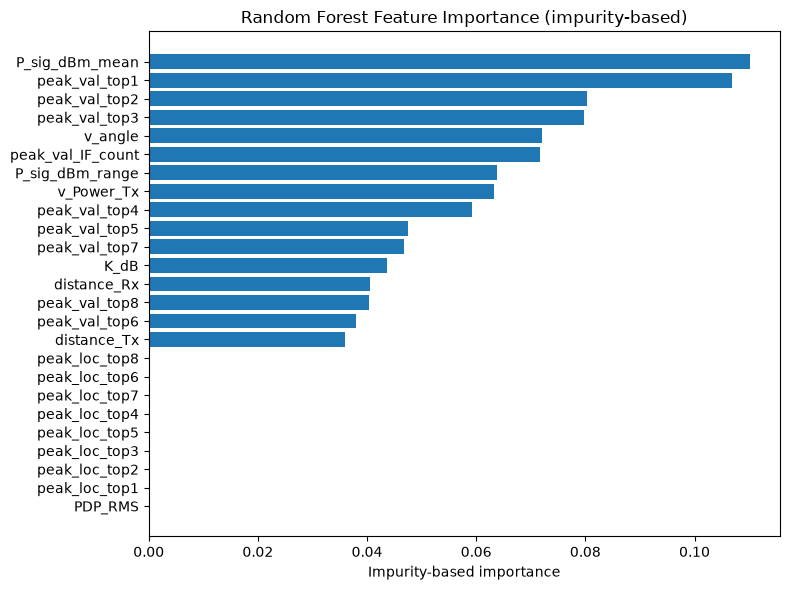

P_sig_dBm_mean         0.1102
peak_val_top1          0.1068
peak_val_top2          0.0803
peak_val_top3          0.0797
v_angle                0.0721
peak_val_IF_count      0.0717
P_sig_dBm_range        0.0638
v_Power_Tx             0.0632
peak_val_top4          0.0591
peak_val_top5          0.0475
peak_val_top7          0.0468
K_dB                   0.0436
distance_Rx            0.0406
peak_val_top8          0.0403
peak_val_top6          0.0380
distance_Tx            0.0360
peak_loc_top8          0.0001
peak_loc_top6          0.0001
peak_loc_top7          0.0001
peak_loc_top4          0.0000
peak_loc_top5          0.0000
peak_loc_top3          0.0000
peak_loc_top2          0.0000
peak_loc_top1          0.0000
PDP_RMS                0.0000


In [52]:
importances = model.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    [features.feature_names[i] for i in order][::-1],
    importances[order][::-1],
)
plt.xlabel("Impurity-based importance")
plt.title("Random Forest Feature Importance (impurity-based)")
plt.tight_layout()
plt.show()

for i in order:
    print(f"{features.feature_names[i]:22s} {importances[i]:.4f}")

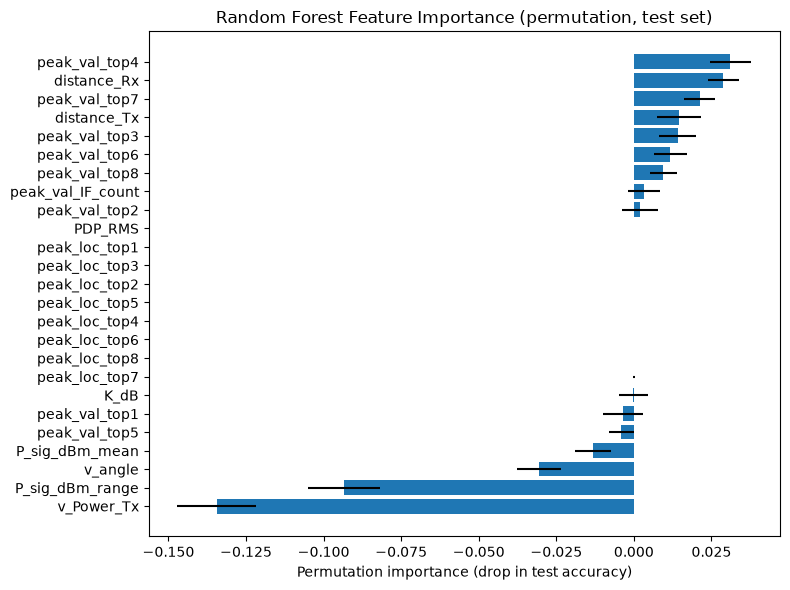

peak_val_top4          0.0311 +/- 0.0067
distance_Rx            0.0288 +/- 0.0050
peak_val_top7          0.0211 +/- 0.0049
distance_Tx            0.0146 +/- 0.0071
peak_val_top3          0.0141 +/- 0.0059
peak_val_top6          0.0117 +/- 0.0054
peak_val_top8          0.0094 +/- 0.0044
peak_val_IF_count      0.0032 +/- 0.0051
peak_val_top2          0.0020 +/- 0.0058
PDP_RMS                0.0000 +/- 0.0000
peak_loc_top1          0.0000 +/- 0.0000
peak_loc_top3          0.0000 +/- 0.0000
peak_loc_top2          0.0000 +/- 0.0000
peak_loc_top5          0.0000 +/- 0.0000
peak_loc_top4          0.0000 +/- 0.0000
peak_loc_top6          0.0000 +/- 0.0000
peak_loc_top8          0.0000 +/- 0.0000
peak_loc_top7          -0.0001 +/- 0.0003
K_dB                   -0.0002 +/- 0.0047
peak_val_top1          -0.0033 +/- 0.0064
peak_val_top5          -0.0040 +/- 0.0041
P_sig_dBm_mean         -0.0131 +/- 0.0058
v_angle                -0.0306 +/- 0.0072
P_sig_dBm_range        -0.0934 +/- 0.0116
v_Power_T

In [53]:
perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=SEED,
    n_jobs=-1,
)

perm_order = np.argsort(perm_result.importances_mean)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    [features.feature_names[i] for i in perm_order][::-1],
    perm_result.importances_mean[perm_order][::-1],
    xerr=perm_result.importances_std[perm_order][::-1],
)
plt.xlabel("Permutation importance (drop in test accuracy)")
plt.title("Random Forest Feature Importance (permutation, test set)")
plt.tight_layout()
plt.show()

for i in perm_order:
    print(
        f"{features.feature_names[i]:22s} "
        f"{perm_result.importances_mean[i]:.4f} +/- {perm_result.importances_std[i]:.4f}"
    )

### Grouped importance: aux vs. peak-structured features

Since the notebook is also testing the hypothesis that most of the useful signal lives in the resolved multipath peaks rather than the per-row aux stats, it's worth summing permutation importance within each feature group.

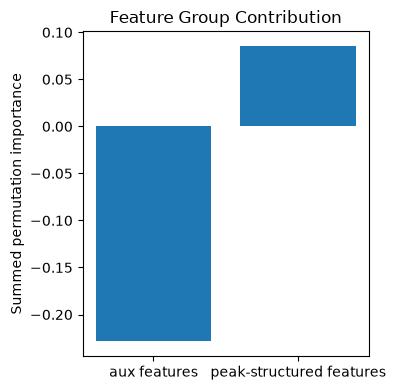

Aux features total importance:  -0.2283
Peak features total importance: 0.0854


In [54]:
aux_names_set = set(AUX_FEATURE_NAMES)
peak_names_set = set(PEAK_STRUCT_FEATURE_NAMES)

aux_importance_sum = sum(
    perm_result.importances_mean[i] for i, name in enumerate(features.feature_names) if name in aux_names_set
)
peak_importance_sum = sum(
    perm_result.importances_mean[i] for i, name in enumerate(features.feature_names) if name in peak_names_set
)

plt.figure(figsize=(4, 4))
plt.bar(["aux features", "peak-structured features"], [aux_importance_sum, peak_importance_sum])
plt.ylabel("Summed permutation importance")
plt.title("Feature Group Contribution")
plt.tight_layout()
plt.show()

print(f"Aux features total importance:  {aux_importance_sum:.4f}")
print(f"Peak features total importance: {peak_importance_sum:.4f}")

# 11. Grouped K-Fold Cross-Validation (Robustness Check)

Same motivation as the MLP notebook: with a single train/val/test split, only a handful of files per class end up in the test set, so the test accuracy above can swing depending on which files happened to land there. We repeat training with grouped, stratified K-fold cross-validation (splitting by *file*, never by row) and report the mean/std test accuracy **and** the mean feature importance across folds, so we can also see how stable the importance ranking is, not just the accuracy.

In [55]:
def grouped_kfold_splits(
    meta: List[Dict[str, Any]],
    labels: np.ndarray,
    n_splits: int = 5,
    seed: int = 42,
):
    """Yield (train_indices, test_indices) for grouped, stratified K-fold CV by file."""
    rng = random.Random(seed)
    labels = np.asarray(labels)

    file_to_label: Dict[str, int] = {}
    file_to_row_indices: Dict[str, List[int]] = {}

    for idx, row_meta in enumerate(meta):
        fname = row_meta["filename"]
        file_to_label.setdefault(fname, int(labels[idx]))
        file_to_row_indices.setdefault(fname, []).append(idx)

    files_by_label: Dict[int, List[str]] = {}
    for fname, label in file_to_label.items():
        files_by_label.setdefault(label, []).append(fname)

    fold_files: List[List[str]] = [[] for _ in range(n_splits)]
    for label, files in files_by_label.items():
        files = list(files)
        rng.shuffle(files)
        for i, fname in enumerate(files):
            fold_files[i % n_splits].append(fname)

    for fold_idx in range(n_splits):
        test_files = set(fold_files[fold_idx])
        train_files = [f for f in file_to_label if f not in test_files]

        train_indices = [i for fname in train_files for i in file_to_row_indices[fname]]
        test_indices = [i for fname in test_files for i in file_to_row_indices[fname]]

        rng.shuffle(train_indices)
        rng.shuffle(test_indices)

        yield fold_idx, train_indices, test_indices, sorted(test_files)

In [56]:
N_FOLDS = 4  # TODO: try 4-6. Limited by how many files per class you have.

fold_test_accuracies = []
fold_importances = []

for fold_idx, fold_train_idx, fold_test_idx, fold_test_files in grouped_kfold_splits(
    features.meta, features.y, n_splits=N_FOLDS, seed=SEED
):
    fold_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED + fold_idx,
        n_jobs=-1,
        **best_params,
    )
    fold_model.fit(features.X[fold_train_idx], features.y[fold_train_idx])

    fold_test_acc = accuracy_score(
        features.y[fold_test_idx], fold_model.predict(features.X[fold_test_idx])
    )
    fold_test_accuracies.append(fold_test_acc)
    fold_importances.append(fold_model.feature_importances_)

    print(
        f"Fold {fold_idx + 1}/{N_FOLDS} | "
        f"train rows: {len(fold_train_idx)} | "
        f"test rows: {len(fold_test_idx)} | "
        f"test files: {fold_test_files} | "
        f"test accuracy: {100 * fold_test_acc:.2f}%"
    )

fold_test_accuracies = np.asarray(fold_test_accuracies)
fold_importances = np.asarray(fold_importances)

print()
print(
    f"Mean test accuracy across {N_FOLDS} folds: "
    f"{100 * fold_test_accuracies.mean():.2f}% "
    f"(+/- {100 * fold_test_accuracies.std():.2f}%)"
)

Fold 1/4 | train rows: 1872 | test rows: 720 | test files: ['data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_176.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle5_Power_500.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle65_Power_125.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle65_Power_500.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_176.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_250.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle65_Power_354.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle45_Power_354.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle65_Power_354.mat', 'data_BW_4GHz_RF_300GHzWood_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzWood_Angle5_Power_125.mat', 'data_BW_4GHz_RF_300GHzWood_Angle65_Power_125.mat', 'data_BW_4GHz_RF_300GHzWood_Angle65_Power_500.mat'] | test accuracy: 48.06%
Fold 2/4 | train rows: 1872 | test rows: 720 | test files: ['data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_354.mat', 'dat

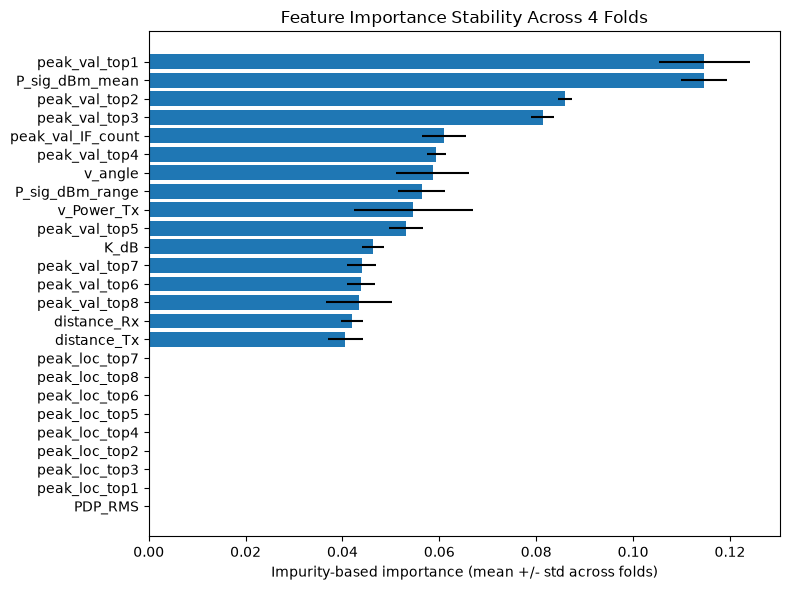

Feature importance, averaged across folds (sorted, most important first):
peak_val_top1          0.1147 +/- 0.0094
P_sig_dBm_mean         0.1146 +/- 0.0047
peak_val_top2          0.0860 +/- 0.0015
peak_val_top3          0.0813 +/- 0.0024
peak_val_IF_count      0.0609 +/- 0.0046
peak_val_top4          0.0594 +/- 0.0019
v_angle                0.0586 +/- 0.0076
P_sig_dBm_range        0.0563 +/- 0.0048
v_Power_Tx             0.0547 +/- 0.0123
peak_val_top5          0.0531 +/- 0.0035
K_dB                   0.0463 +/- 0.0023
peak_val_top7          0.0439 +/- 0.0030
peak_val_top6          0.0439 +/- 0.0029
peak_val_top8          0.0434 +/- 0.0068
distance_Rx            0.0420 +/- 0.0022
distance_Tx            0.0405 +/- 0.0036
peak_loc_top7          0.0001 +/- 0.0000
peak_loc_top8          0.0001 +/- 0.0001
peak_loc_top6          0.0001 +/- 0.0000
peak_loc_top5          0.0000 +/- 0.0000
peak_loc_top4          0.0000 +/- 0.0000
peak_loc_top2          0.0000 +/- 0.0000
peak_loc_top3          0

In [57]:
mean_importance = fold_importances.mean(axis=0)
std_importance = fold_importances.std(axis=0)
stable_order = np.argsort(mean_importance)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    [features.feature_names[i] for i in stable_order][::-1],
    mean_importance[stable_order][::-1],
    xerr=std_importance[stable_order][::-1],
)
plt.xlabel("Impurity-based importance (mean +/- std across folds)")
plt.title(f"Feature Importance Stability Across {N_FOLDS} Folds")
plt.tight_layout()
plt.show()

print("Feature importance, averaged across folds (sorted, most important first):")
for i in stable_order:
    print(f"{features.feature_names[i]:22s} {mean_importance[i]:.4f} +/- {std_importance[i]:.4f}")

## 12. Permutation Importance over k-Folds

Fold 1/4: permutation importance computed on 720 test rows
Fold 2/4: permutation importance computed on 720 test rows
Fold 3/4: permutation importance computed on 624 test rows
Fold 4/4: permutation importance computed on 528 test rows


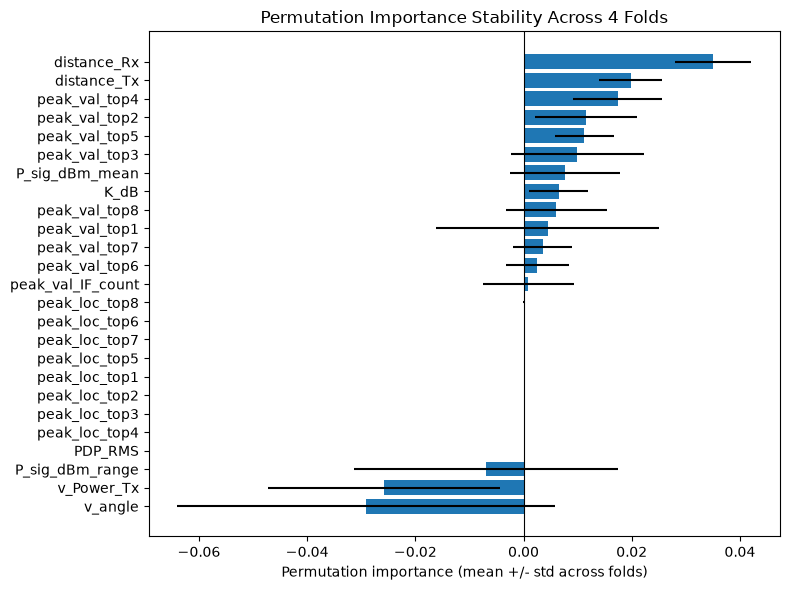

Permutation importance, averaged across folds (sorted, most important first):
distance_Rx            0.0350 +/- 0.0071
distance_Tx            0.0199 +/- 0.0058
peak_val_top4          0.0174 +/- 0.0082
peak_val_top2          0.0116 +/- 0.0094
peak_val_top5          0.0113 +/- 0.0054
peak_val_top3          0.0099 +/- 0.0123
P_sig_dBm_mean         0.0077 +/- 0.0101
K_dB                   0.0065 +/- 0.0054
peak_val_top8          0.0060 +/- 0.0093
peak_val_top1          0.0044 +/- 0.0206
peak_val_top7          0.0035 +/- 0.0054
peak_val_top6          0.0026 +/- 0.0059
peak_val_IF_count      0.0009 +/- 0.0084
peak_loc_top8          0.0000 +/- 0.0000
peak_loc_top6          0.0000 +/- 0.0000
peak_loc_top7          0.0000 +/- 0.0000
peak_loc_top5          0.0000 +/- 0.0000
peak_loc_top1          0.0000 +/- 0.0000
peak_loc_top2          0.0000 +/- 0.0000
peak_loc_top3          0.0000 +/- 0.0000
peak_loc_top4          0.0000 +/- 0.0000
PDP_RMS                0.0000 +/- 0.0000
P_sig_dBm_range     

In [58]:
# Permutation importance across folds -- unlike the single-split version above, each fold's
# permutation importance is measured against a different set of held-out files, so this tells
# us whether a feature's importance holds up across different train/test splits or was an
# artifact of one particular (possibly unlucky) split.

fold_perm_importances = []

for fold_idx, fold_train_idx, fold_test_idx, fold_test_files in grouped_kfold_splits(
    features.meta, features.y, n_splits=N_FOLDS, seed=SEED
):
    fold_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED + fold_idx,
        n_jobs=-1,
        **best_params,
    )
    fold_model.fit(features.X[fold_train_idx], features.y[fold_train_idx])

    fold_perm_result = permutation_importance(
        fold_model,
        features.X[fold_test_idx],
        features.y[fold_test_idx],
        n_repeats=30,
        random_state=SEED,
        n_jobs=-1,
    )
    fold_perm_importances.append(fold_perm_result.importances_mean)

    print(f"Fold {fold_idx + 1}/{N_FOLDS}: permutation importance computed on {len(fold_test_idx)} test rows")

fold_perm_importances = np.asarray(fold_perm_importances)  # shape: (n_folds, n_features)

mean_perm_importance = fold_perm_importances.mean(axis=0)
std_perm_importance = fold_perm_importances.std(axis=0)
perm_stable_order = np.argsort(mean_perm_importance)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    [features.feature_names[i] for i in perm_stable_order][::-1],
    mean_perm_importance[perm_stable_order][::-1],
    xerr=std_perm_importance[perm_stable_order][::-1],
)
plt.xlabel("Permutation importance (mean +/- std across folds)")
plt.title(f"Permutation Importance Stability Across {N_FOLDS} Folds")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Permutation importance, averaged across folds (sorted, most important first):")
for i in perm_stable_order:
    print(f"{features.feature_names[i]:22s} {mean_perm_importance[i]:.4f} +/- {std_perm_importance[i]:.4f}")

# 12. Takeaways

We are seeing really ridiculous values for feature importance, especially in the permutation importance, which should be a better measure of importance in this instance. My thoughts are to remove all the `loc` features, as they all have 0 importance. We should also remove the `v_angle` and `v_Power_Tx` features. They are essentially acting as an ID, and the model is often memorizing them, and assigning a material based on that. 